# Training Curves Plotting
Notebook per visualizzare le curve di training a partire dal file `training_history.json` presente nelle cartelle run di `experiments/runs`.

In [100]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# Imposta il run desiderato; di default usa l'ultimo run (ordinato per nome) che contiene training_history.json
runs_dir = Path('../experiments/runs')

candidate_runs = sorted(
    [p for p in runs_dir.iterdir() if p.is_dir() and (p / 'training_history.json').exists()]
)

if not candidate_runs:
    raise FileNotFoundError(f'Nessun run con training_history.json trovato in {runs_dir.resolve()}')

# Per usare un run specifico, decommenta e modifica la riga seguente:
#run_dir = runs_dir / 'triplet-hardmining-20260417-183947'
run_dir = candidate_runs[-1]

history_path = run_dir / 'training_history.json'
print(f'Using run:          {run_dir.name}')
print(f'History file:       {history_path}')

Using run:          base-20260416-155153
History file:       ..\experiments\runs\base-20260416-155153\training_history.json


In [102]:
# Carica il JSON e costruisce il DataFrame
with history_path.open('r', encoding='utf-8') as f:
    history = json.load(f)

epoch_rows = []
for entry in history:
    tr = entry.get('train', {})
    vl = entry.get('val', {})
    map_at_k = vl.get('map_at_k', {})

    row = {
        'epoch':               tr.get('epoch'),
        'train_loss':          tr.get('loss'),
        'hard_positive_dist':  tr.get('hard_positive_distance'),
        'hard_negative_dist':  tr.get('hard_negative_distance'),
        'valid_anchors':       tr.get('valid_anchors'),
        'total_anchors':       tr.get('total_anchors'),
        'anchor_ratio':        (tr['valid_anchors'] / tr['total_anchors']
                                if tr.get('total_anchors') else float('nan')),
        'train_elapsed_s':     tr.get('elapsed_seconds'),
        'val_map1':            float(map_at_k.get('1', float('nan'))),
        'val_map5':            float(map_at_k.get('5', float('nan'))),
        'val_map10':           float(map_at_k.get('10', float('nan'))),
        'monitor_value':       entry.get('monitor_value'),
        'is_best':             entry.get('is_best', False),
        'val_elapsed_s':       vl.get('elapsed_seconds'),
    }
    epoch_rows.append(row)

df_epoch = pd.DataFrame(epoch_rows).sort_values('epoch').reset_index(drop=True)

print(f'Epoch records: {len(df_epoch)}')
df_epoch.tail()

Epoch records: 100


,epoch,train_loss,hard_positive_dist,hard_negative_dist,valid_anchors,total_anchors,anchor_ratio,train_elapsed_s,val_map1,val_map5,val_map10,monitor_value,is_best,val_elapsed_s
95,96,0.815733,None,None,None,None,NaN,158.658576,0.519669,0.402343,0.341476,0.402343,True,40.941668
96,97,0.803554,None,None,None,None,NaN,158.500050,0.516410,0.398411,0.338267,0.398411,False,41.227298
97,98,0.789992,None,None,None,None,NaN,158.947111,0.518304,0.400514,0.339984,0.400514,False,39.390120
98,99,0.775774,None,None,None,None,NaN,157.808794,0.516816,0.399553,0.338764,0.399553,False,40.664277
99,100,0.760394,None,None,None,None,NaN,158.145956,0.521089,0.402994,0.342140,0.402994,True,40.618556


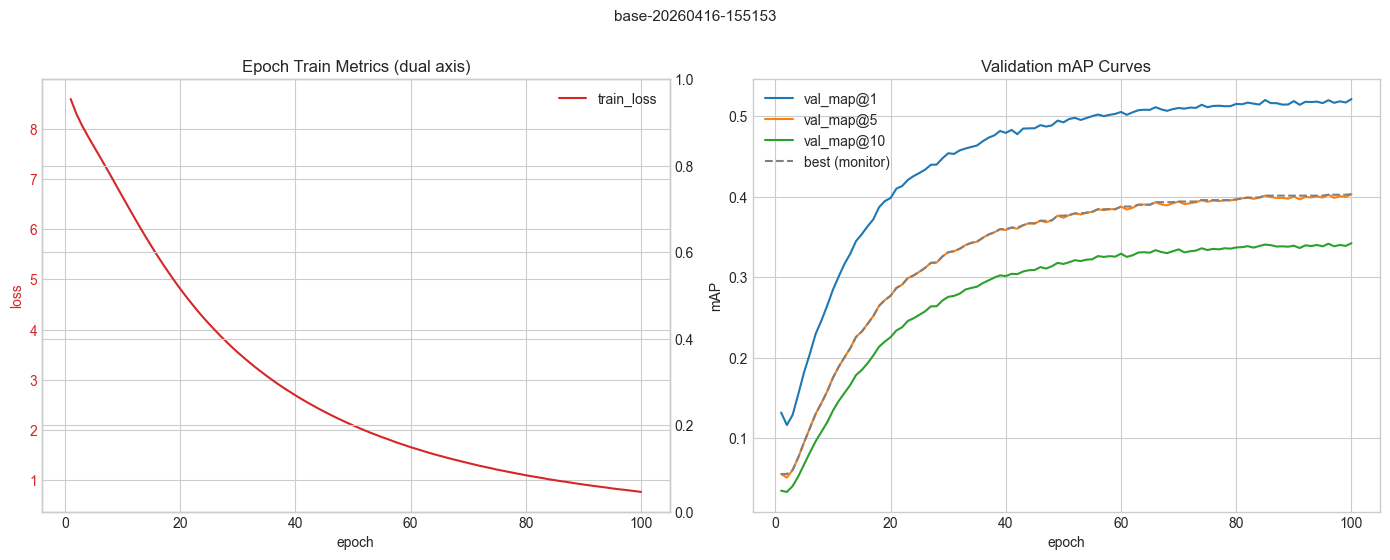

In [103]:
if df_epoch.empty:
    raise ValueError('Nessuna metrica trovata nel file JSON selezionato.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Pannello sinistro: Loss + hard mining distances ---
ax_loss = axes[0]
ax_dist = ax_loss.twinx()

loss_line = ax_loss.plot(
    df_epoch['epoch'],
    df_epoch['train_loss'],
    color='tab:red',
    label='train_loss',
)

aux_lines = []
if df_epoch['hard_positive_dist'].notna().any() or df_epoch['hard_negative_dist'].notna().any():
    aux_lines += ax_dist.plot(
        df_epoch['epoch'],
        df_epoch['hard_positive_dist'],
        color='tab:orange',
        label='hard_pos_dist',
    )
    aux_lines += ax_dist.plot(
        df_epoch['epoch'],
        df_epoch['hard_negative_dist'],
        color='tab:purple',
        label='hard_neg_dist',
    )
    ax_dist.set_ylabel('hard mining distance')

ax_loss.set_title('Epoch Train Metrics (dual axis)')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss', color='tab:red')
ax_loss.tick_params(axis='y', labelcolor='tab:red')

lines = loss_line + aux_lines
labels = [ln.get_label() for ln in lines]
ax_loss.legend(lines, labels, loc='best')

# --- Pannello destro: Validation mAP ---
axes[1].plot(df_epoch['epoch'], df_epoch['val_map1'],  label='val_map@1')
axes[1].plot(df_epoch['epoch'], df_epoch['val_map5'],  label='val_map@5')
axes[1].plot(df_epoch['epoch'], df_epoch['val_map10'], label='val_map@10')

# Linea tratteggiata per il best monitor value raggiunto finora
df_epoch['best_val'] = df_epoch['monitor_value'].cummax()
axes[1].plot(
    df_epoch['epoch'],
    df_epoch['best_val'],
    linestyle='--',
    color='gray', 
    linewidth=1.5, 
    label='best (monitor)'
)

axes[1].set_title('Validation mAP Curves')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

fig.suptitle(run_dir.name, fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

In [104]:
# Salvataggio opzionale della figura nella cartella del run
save_fig = True
output_path = run_dir / 'training_curves.png'

if save_fig:
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'Figura salvata in: {output_path.resolve()}')
else:
    print('save_fig=False: nessun file salvato')

Figura salvata in: C:\Users\jzmat\Desktop\uni\ml-face-recognition\experiments\runs\base-20260416-155153\training_curves.png
